# Aula – Regressão Linear: Previsão, Erro e Avaliação de Modelos

## UC4 – Estatística aplicada à Inteligência Artificial

### Objetivos da aula
- Entender o que é regressão linear.
- Diferenciar correlação de regressão.
- Interpretar a equação da reta.
- Entender coeficiente angular e intercepto.
- Fazer previsões.
- Entender o que é erro em modelos preditivos.
- Compreender MAE, MSE, RMSE e R².
- Aplicar regressão linear com `numpy` e `scikit-learn`.
- Interpretar resultados de modelos.
- Relacionar regressão linear com Inteligência Artificial.

## Roteiro da aula

1. Revisão: correlação  
2. O que é regressão linear  
3. Equação da reta  
4. Coeficiente angular e intercepto  
5. Ajuste de uma reta aos dados  
6. Previsão  
7. Erro do modelo  
8. MAE  
9. MSE  
10. RMSE  
11. R²  
12. Regressão com `scikit-learn`  
13. Interpretação profissional dos resultados  
14. Limitações da regressão linear  
15. Aplicações em IA  
16. Exercícios  
17. Desafio final

# 1. Revisão: correlação

Na aula anterior, estudamos correlação.

A correlação mede a relação entre duas variáveis.

Exemplo:

- horas de estudo e nota;
- publicidade e vendas;
- experiência e salário.

A correlação responde:

> Existe relação entre as variáveis?

Mas ela não cria um modelo de previsão.

Para prever valores, usamos regressão.

# 2. Correlação x Regressão

| Conceito | Pergunta que responde |
|---|---|
| Correlação | Existe relação entre as variáveis? |
| Regressão | Posso usar essa relação para prever valores? |

Exemplo:

Se existe uma relação entre horas de estudo e nota, a regressão tenta criar uma equação para prever a nota de um aluno a partir das horas estudadas.

# 3. O que é regressão linear?

Regressão linear é uma técnica estatística usada para modelar a relação entre uma variável de entrada e uma variável de saída.

Ela tenta ajustar uma reta aos dados.

A ideia é encontrar uma reta que represente bem o comportamento dos pontos.

Essa reta pode ser usada para fazer previsões.

# 4. Equação da regressão linear

A regressão linear simples usa a equação:

\[
y = ax + b
\]

Onde:

- \(y\) = valor previsto;
- \(x\) = variável de entrada;
- \(a\) = coeficiente angular;
- \(b\) = intercepto ou coeficiente linear.

## Interpretação

### Coeficiente angular \(a\)
Mostra quanto \(y\) muda quando \(x\) aumenta 1 unidade.

Exemplo:

Se:

\[
y = 1,5x + 2
\]

então, para cada aumento de 1 unidade em \(x\), o valor previsto de \(y\) aumenta 1,5.

### Intercepto \(b\)
Mostra o valor previsto de \(y\) quando \(x = 0\).

Nem sempre esse valor tem interpretação real no contexto.

# 5. Exemplo inicial: horas de estudo e nota

Vamos criar uma base simples.

| Horas de estudo | Nota |
|---|---|
| 1 | 3 |
| 2 | 4 |
| 3 | 5 |
| 4 | 7 |
| 5 | 8 |

Queremos prever a nota a partir das horas de estudo.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

horas = np.array([1, 2, 3, 4, 5])
notas = np.array([3, 4, 5, 7, 8])

df = pd.DataFrame({
    "horas_estudo": horas,
    "nota": notas,
})

df

,horas_estudo,nota
0,1,3
1,2,4
2,3,5
3,4,7
4,5,8


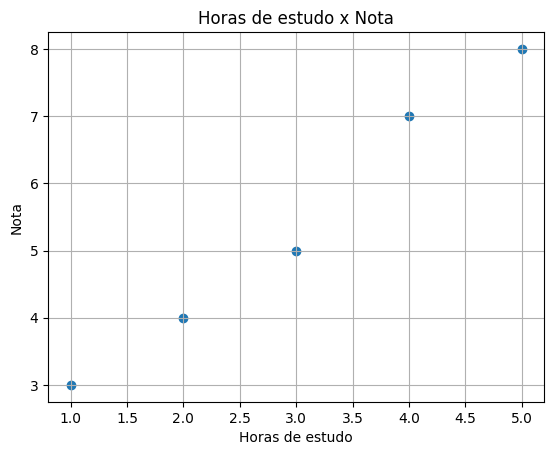

In [6]:
plt.scatter(df["horas_estudo"], df["nota"])
plt.title("Horas de estudo x Nota")
plt.xlabel("Horas de estudo")
plt.ylabel("Nota")
plt.grid(True)
plt.show()

# 6. Ajustando uma reta com `numpy`

Podemos usar `np.polyfit` para ajustar uma reta.

O parâmetro `1` indica que queremos uma reta de grau 1.

Uma reta tem formato:

\[
y = ax + b
\]

O `np.polyfit` retorna:

- coeficiente angular;
- intercepto.

In [3]:
coeficientes = np.polyfit(horas, notas, 1)

a = coeficientes[0]
b = coeficientes[1]

a, b

(np.float64(1.3), np.float64(1.4999999999999971))

# 7. Interpretando os coeficientes

Suponha que o resultado seja aproximadamente:

\[
y = 1,3x + 1,4
\]

Isso significa:

- para cada hora extra de estudo, a nota prevista aumenta aproximadamente 1,3 ponto;
- se alguém estudasse 0 horas, a reta preveria nota próxima de 1,4.

Atenção:

O intercepto nem sempre representa algo real. Ele é principalmente parte da equação matemática da reta.

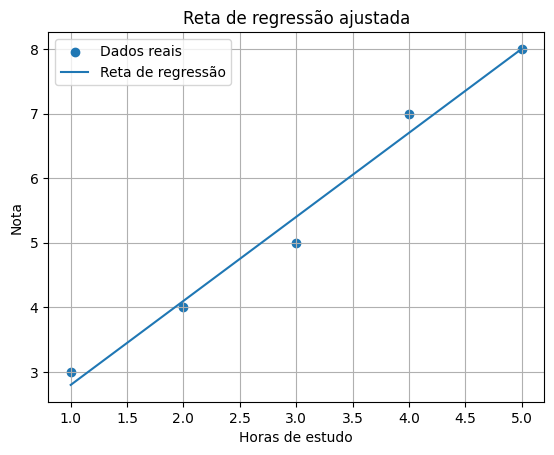

In [4]:
notas_previstas = a * horas + b

plt.scatter(horas, notas, label="Dados reais")
plt.plot(horas, notas_previstas, label="Reta de regressão")

plt.title("Reta de regressão ajustada")
plt.xlabel("Horas de estudo")
plt.ylabel("Nota")
plt.legend()
plt.grid(True)
plt.show()

# 8. Fazendo uma previsão

Agora podemos prever a nota de um aluno que estudou 6 horas.

Usamos a equação:

\[
y = ax + b
\]

In [ ]:
nota_6h = a * 6 + b
nota_6h

# 9. O que é erro em regressão?

Um modelo raramente acerta exatamente todos os valores.

O erro é a diferença entre:

- valor real;
- valor previsto.

$$
erro = y_{real} - y_{previsto}
$$

Se o erro é positivo, o modelo previu abaixo do real.

Se o erro é negativo, o modelo previu acima do real.

Se o erro é próximo de zero, a previsão foi boa.

In [9]:
df_resultados = pd.DataFrame({
    "horas_estudo": horas,
    "nota_real": notas,
    "nota_prevista": notas_previstas
})

df_resultados["erro"] = df_resultados["nota_real"] - df_resultados["nota_prevista"]

df_resultados

,horas_estudo,nota_real,nota_prevista,erro
0,1,3,2.80,0.20
1,2,4,4.10,-0.10
2,3,5,5.40,-0.40
3,4,7,6.70,0.30
4,5,8,8.00,0.00


# 10. Por que medir erro?

Medir erro serve para responder:

> O modelo está prevendo bem?

Sem medir erro, não sabemos se o modelo é bom.

Na prática profissional, não basta treinar um modelo.  
É necessário avaliar a qualidade das previsões.

Por isso usamos métricas como:

- MAE;
- MSE;
- RMSE;
- R².

# 11. MAE – Mean Absolute Error

MAE significa **Erro Absoluto Médio**.

Ele calcula a média dos erros em valor absoluto.

$$
MAE = \frac{1}{n}\sum |y_{real} - y_{previsto}|
$$

## Para que serve?

O MAE mostra, em média, quanto o modelo erra.

Exemplo:

Se o MAE de um modelo de notas é 0,5, significa que o modelo erra, em média, cerca de 0,5 ponto.

## Vantagens
- Fácil de interpretar.
- Está na mesma unidade do alvo.

## Limitação
- Não penaliza erros grandes tão fortemente quanto o MSE/RMSE.

In [10]:
mae = np.mean(np.abs(df_resultados["erro"]))
mae

np.float64(0.20000000000000054)

# 12. Interpretando o MAE

Se MAE = 0,3 em um problema de notas, o modelo erra em média 0,3 ponto.

Se MAE = 2000 em um problema de salário, o modelo erra em média R$ 2.000.

Ou seja:

> O MAE sempre deve ser interpretado na unidade da variável que estamos prevendo.

# 13. MSE – Mean Squared Error

MSE significa **Erro Quadrático Médio**.

Ele calcula a média dos erros ao quadrado.

$$
MSE = \frac{1}{n}\sum (y_{real} - y_{previsto})^2
$$

## Para que serve?

O MSE penaliza mais os erros grandes.

Isso acontece porque os erros são elevados ao quadrado.

Exemplo:

- erro 2 vira 4;
- erro 10 vira 100.

## Vantagem
- Dá mais peso a erros grandes.

## Limitação
- Fica em unidade ao quadrado.
- Pode ser menos intuitivo.

In [ ]:
mse = np.mean(df_resultados["erro"] ** 2)
mse

# 14. Interpretando o MSE

O MSE é útil quando queremos punir erros grandes.

Exemplo:

Em um sistema financeiro, errar pouco muitas vezes pode ser aceitável.  
Mas errar muito em alguns casos pode ser um problema grave.

O MSE ajuda a destacar esses erros maiores.

Por outro lado, como ele está em unidade ao quadrado, é menos intuitivo para explicar para pessoas não técnicas.

# 15. RMSE – Root Mean Squared Error

RMSE significa **Raiz do Erro Quadrático Médio**.

Ele é a raiz quadrada do MSE.

$$
RMSE = \sqrt{MSE}
$$

## Para que serve?

O RMSE também penaliza erros grandes, mas volta para a unidade original do problema.

Exemplo:

Se estamos prevendo nota, o RMSE está em pontos de nota.  
Se estamos prevendo salário, o RMSE está em reais.

## Vantagem
- Penaliza erros grandes.
- É mais interpretável que o MSE.

## Limitação
- Pode ser muito influenciado por outliers.

In [ ]:
rmse = np.sqrt(mse)
rmse

# 16. Comparando MAE e RMSE

## MAE
- mede erro médio absoluto;
- mais simples de interpretar;
- menos sensível a erros extremos.

## RMSE
- também mede erro;
- penaliza mais erros grandes;
- mais sensível a outliers.

### Quando usar MAE?
Quando você quer uma noção simples do erro médio.

### Quando usar RMSE?
Quando erros grandes são muito preocupantes.

# 17. R² – Coeficiente de Determinação

O R² mede quanto da variação da variável alvo é explicada pelo modelo.

$$
R^2 = 1 - \frac{SS_{res}}{SS_{tot}}
$$

Onde:

- $SS_{res}$ = soma dos erros ao quadrado;
- $SS_{tot}$ = variação total dos dados em relação à média.

## Interpretação

- R² próximo de 1: modelo explica bem os dados.
- R² próximo de 0: modelo explica pouco.
- R² negativo: modelo pode estar pior do que simplesmente usar a média.

In [ ]:
ss_res = np.sum((notas - notas_previstas) ** 2)
ss_tot = np.sum((notas - np.mean(notas)) ** 2)

r2 = 1 - (ss_res / ss_tot)

r2

# 18. Interpretando o R²

Se R² = 0,95, podemos dizer:

> O modelo explica aproximadamente 95% da variação dos dados.

Mas cuidado:

- R² alto não prova causalidade;
- R² alto não garante que o modelo será bom em novos dados;
- R² pode ser enganoso se houver poucos dados;
- R² não substitui análise visual e interpretação.

# 19. Resumo das métricas

| Métrica | O que mede | Interpretação |
|---|---|---|
| MAE | erro absoluto médio | erro médio na unidade original |
| MSE | erro quadrático médio | penaliza erros grandes |
| RMSE | raiz do MSE | erro na unidade original, penalizando erros grandes |
| R² | variação explicada | qualidade geral do ajuste |

## Exemplo prático

Se estamos prevendo salários:

- MAE = 500: erro médio de R$ 500;
- RMSE = 900: existem erros grandes puxando a métrica para cima;
- R² = 0,85: o modelo explica boa parte da variação dos salários.

# 20. Usando `scikit-learn`

Na prática profissional, usamos bibliotecas de Machine Learning.

A biblioteca mais usada para modelos tradicionais em Python é o `scikit-learn`.

Ela permite:

- criar modelos;
- treinar modelos;
- fazer previsões;
- avaliar modelos.

Agora vamos repetir a regressão usando `LinearRegression`.

# 21. Formato esperado pelo `scikit-learn`

O `scikit-learn` espera que:

- `X` seja uma matriz/DataFrame com as variáveis de entrada;
- `y` seja o vetor/coluna com o alvo que queremos prever.

Mesmo quando usamos apenas uma variável, `X` precisa estar no formato de matriz.

Por isso usamos:

```python
X = horas.reshape(-1, 1)
```

Isso transforma:

```python
[1, 2, 3, 4, 5]
```

em:

```python
[[1],
 [2],
 [3],
 [4],
 [5]]
```

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X = horas.reshape(-1, 1)
y = notas

X, y

In [ ]:
X

In [ ]:
x

# 22. Criando e treinando o modelo

O processo tem três etapas principais:

1. Criar o modelo.
2. Treinar o modelo com `.fit(X, y)`.
3. Fazer previsões com `.predict(X)`.

O método `.fit()` é onde o modelo aprende a relação entre X e y.

In [ ]:
modelo = LinearRegression()

modelo.fit(X, y)

# 23. Coeficientes no `scikit-learn`

Depois de treinar, podemos acessar:

- `modelo.coef_`: coeficiente angular;
- `modelo.intercept_`: intercepto.

No caso de regressão linear simples, isso corresponde a:

\[
y = ax + b
\]

In [ ]:
modelo.coef_, modelo.intercept_

# 24. Fazendo previsões com o modelo

Agora podemos usar o modelo treinado para prever a nota de um aluno que estudou 6 horas.

O método `.predict()` espera uma matriz.

Por isso usamos:

```python
[[6]]
```

In [ ]:
modelo.predict([[6]])

# 25. Previsões para todos os dados

Vamos prever as notas para os próprios dados usados no treinamento.

In [ ]:
y_pred = modelo.predict(X)

df_sklearn = pd.DataFrame({
    "horas_estudo": horas,
    "nota_real": y,
    "nota_prevista": y_pred,
    "erro": y - y_pred
})

df_sklearn

# 26. Métricas com `scikit-learn`

O `scikit-learn` já possui funções prontas para calcular métricas.

Usaremos:

- `mean_absolute_error`
- `mean_squared_error`
- `r2_score`

Para RMSE, calculamos a raiz do MSE.

In [ ]:
mae_sklearn = mean_absolute_error(y, y_pred)
mse_sklearn = mean_squared_error(y, y_pred)
rmse_sklearn = np.sqrt(mse_sklearn)
r2_sklearn = r2_score(y, y_pred)

mae_sklearn, mse_sklearn, rmse_sklearn, r2_sklearn

# 27. Visualizando o modelo

Sempre que possível, visualize o ajuste.

Em regressão linear simples, isso é fácil porque temos apenas uma variável de entrada.

In [ ]:
plt.scatter(horas, notas, label="Dados reais")
plt.plot(horas, y_pred, label="Modelo de regressão")

plt.title("Regressão linear com scikit-learn")
plt.xlabel("Horas de estudo")
plt.ylabel("Nota")
plt.legend()
plt.grid(True)
plt.show()

# 28. Interpretação profissional do resultado

Ao apresentar um modelo, não basta dizer:

> Treinei uma regressão.

É preciso interpretar:

1. Qual variável foi usada para prever?
2. Qual é o alvo?
3. Qual o sentido da relação?
4. O coeficiente faz sentido?
5. Qual o erro médio?
6. O R² é aceitável?
7. O modelo é confiável para novos dados?
8. Existem limitações?

Exemplo de conclusão:

> O modelo indica que, para cada hora adicional de estudo, a nota prevista aumenta em aproximadamente 1,3 ponto. O erro médio absoluto foi baixo na base analisada, e o R² indica bom ajuste. Porém, a base é pequena, então o modelo deve ser validado com mais dados.

# 29. Treino e teste: cuidado importante

Até agora avaliamos o modelo nos mesmos dados usados para treino.

Isso é útil para aprender, mas em projetos reais pode ser perigoso.

O correto é separar:

- dados de treino: usados para o modelo aprender;
- dados de teste: usados para avaliar o desempenho em dados novos.

Isso ajuda a verificar se o modelo realmente aprendeu ou apenas decorou.

In [ ]:
from sklearn.model_selection import train_test_split

# Base um pouco maior para exemplo
df_maior = pd.DataFrame({
    "horas_estudo": [1,2,2,3,3,4,4,5,5,6,6,7,8,9,10],
    "nota": [2,3,4,4,5,5,6,7,7,8,8,9,9,10,10]
})

X = df_maior[["horas_estudo"]]
y = df_maior["nota"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

modelo = LinearRegression()
modelo.fit(X_train, y_train)

y_pred_test = modelo.predict(X_test)

pd.DataFrame({
    "real": y_test,
    "previsto": y_pred_test
})

In [ ]:
mae_teste = mean_absolute_error(y_test, y_pred_test)
rmse_teste = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_teste = r2_score(y_test, y_pred_test)

mae_teste, rmse_teste, r2_teste

# 30. Regressão linear múltipla

A regressão linear simples usa uma variável de entrada.

A regressão linear múltipla usa várias variáveis.

Exemplo:

Queremos prever a nota usando:

- horas de estudo;
- frequência;
- tempo no celular.

A equação fica parecida com:

\[
nota = a_1(horas) + a_2(frequência) + a_3(tempo\_celular) + b
\]

In [ ]:
df_multi = pd.DataFrame({
    "horas_estudo": [1,2,3,4,5,6,7,8,9,10],
    "frequencia": [60,65,70,72,75,80,85,88,92,95],
    "tempo_celular": [9,8,7,7,6,5,4,4,3,2],
    "nota": [2,3,4,5,6,7,8,8,9,10]
})

df_multi

In [ ]:
X = df_multi[["horas_estudo", "frequencia", "tempo_celular"]]
y = df_multi["nota"]

modelo_multi = LinearRegression()
modelo_multi.fit(X, y)

pred_multi = modelo_multi.predict(X)

coeficientes = pd.DataFrame({
    "variavel": X.columns,
    "coeficiente": modelo_multi.coef_
})

coeficientes, modelo_multi.intercept_

# 31. Interpretando coeficientes da regressão múltipla

Cada coeficiente indica o efeito esperado daquela variável, mantendo as outras constantes.

Exemplo:

Se o coeficiente de `horas_estudo` é positivo, o modelo entende que mais horas de estudo tendem a aumentar a nota, considerando as demais variáveis.

Se o coeficiente de `tempo_celular` é negativo, o modelo entende que mais tempo no celular tende a reduzir a nota, considerando as demais variáveis.

Atenção:

Coeficientes precisam ser interpretados com cuidado, principalmente quando as variáveis estão muito correlacionadas entre si.

In [ ]:
mae_multi = mean_absolute_error(y, pred_multi)
rmse_multi = np.sqrt(mean_squared_error(y, pred_multi))
r2_multi = r2_score(y, pred_multi)

mae_multi, rmse_multi, r2_multi

# 32. Limitações da regressão linear

A regressão linear é poderosa, mas tem limitações.

Ela funciona melhor quando:

- a relação é aproximadamente linear;
- os dados não têm outliers muito fortes;
- as variáveis importantes estão presentes;
- os dados são representativos;
- o padrão é relativamente estável.

Pode falhar quando:

- a relação é curva/não linear;
- há muitos outliers;
- faltam variáveis importantes;
- há poucos dados;
- o comportamento muda ao longo do tempo.

In [ ]:
x = np.linspace(-10, 10, 100)
y = x**2

coef = np.polyfit(x, y, 1)
reta = coef[0] * x + coef[1]

plt.scatter(x, y, s=10, label="Dados")
plt.plot(x, reta, label="Reta linear")
plt.title("Exemplo de relação não linear")
plt.legend()
plt.grid(True)
plt.show()

# 33. Interpretação do exemplo não linear

A reta não representa bem a relação.

Nesse caso, o padrão é quadrático.

A regressão linear simples não é adequada.

Poderíamos usar:

- regressão polinomial;
- árvore de decisão;
- random forest;
- modelos mais flexíveis.

# 34. Aplicações reais da regressão linear

## Educação
- prever nota a partir de horas de estudo e frequência.

## Vendas
- prever vendas a partir de investimento em publicidade.

## Finanças
- prever gasto mensal com base em renda e perfil.

## RH
- estimar remuneração com base em experiência e cargo.

## Sistemas
- prever tempo de resposta com base em carga do sistema.

## Governo e dados públicos
- analisar remuneração, descontos, benefícios e valores líquidos.

# 35. Relação com Inteligência Artificial

A regressão linear é um dos modelos mais clássicos de Machine Learning.

Ela ensina conceitos essenciais:

- treino;
- previsão;
- erro;
- avaliação;
- interpretação;
- generalização.

Mesmo modelos avançados seguem a mesma lógica geral:

1. receber dados;
2. aprender padrões;
3. fazer previsões;
4. medir erro;
5. melhorar o modelo.

# 36. Exercícios resolvidos

## Exercício resolvido 1

Se:

\[
y = 2x + 1
\]

Qual valor previsto para \(x = 5\)?

\[
y = 2(5) + 1 = 11
\]

Resposta: 11.

## Exercício resolvido 2

Um modelo prevê:

- valor real = 8
- valor previsto = 6

Erro:

\[
erro = 8 - 6 = 2
\]

O modelo previu abaixo do valor real.

## Exercício resolvido 3

Se o MAE de um modelo de previsão de salário é R$ 500, o que isso significa?

Significa que, em média, o modelo erra cerca de R$ 500 nas previsões.

## Exercício resolvido 4

Se o R² de um modelo é 0,90, o que isso significa?

Significa que o modelo explica aproximadamente 90% da variação dos dados.

Mas isso não garante causalidade nem desempenho perfeito em dados novos.

# 37. Lista de exercícios – Conceitos

### Exercício 1
O que é regressão linear?

### Exercício 2
Qual a diferença entre correlação e regressão?

### Exercício 3
O que significa prever um valor?

### Exercício 4
O que representa o coeficiente angular?

### Exercício 5
O que representa o intercepto?

### Exercício 6
Por que o intercepto nem sempre tem interpretação prática?

### Exercício 7
O que é erro em um modelo de regressão?

### Exercício 8
Por que medir erro é importante?

### Exercício 9
O que é MAE?

### Exercício 10
O que é MSE?

### Exercício 11
O que é RMSE?

### Exercício 12
O que é R²?

### Exercício 13
Qual a diferença entre MAE e RMSE?

### Exercício 14
Por que o MSE penaliza mais erros grandes?

### Exercício 15
Por que separar treino e teste é importante?

# 38. Lista de exercícios – Cálculo e interpretação

### Exercício 16
Se:

\[
y = 3x + 2
\]

Qual previsão para \(x = 4\)?

### Exercício 17
Se:

\[
y = -2x + 10
\]

Qual previsão para \(x = 3\)?

### Exercício 18
Se o coeficiente angular é negativo, o que isso indica?

### Exercício 19
Se o coeficiente angular é positivo, o que isso indica?

### Exercício 20
Um modelo previu 100, mas o valor real era 120. Qual foi o erro?

### Exercício 21
Um modelo teve MAE = 5 em um problema de previsão de notas de 0 a 100. Interprete.

### Exercício 22
Um modelo teve RMSE muito maior que o MAE. O que isso pode indicar?

### Exercício 23
Um modelo teve R² = 0,05. O que isso sugere?

### Exercício 24
Um modelo teve R² = 0,95. O que isso sugere?

### Exercício 25
R² alto prova causalidade? Explique.

# 39. Lista de exercícios – Python

Use os dados abaixo:

```python
x = [1, 2, 3, 4, 5]
y = [2, 4, 5, 7, 8]
```

### Exercício 26
Faça o gráfico de dispersão.

### Exercício 27
Ajuste uma reta usando `np.polyfit`.

### Exercício 28
Mostre o coeficiente angular e o intercepto.

### Exercício 29
Faça uma previsão para `x = 6`.

### Exercício 30
Calcule os valores previstos para todos os pontos.

### Exercício 31
Calcule o erro de cada ponto.

### Exercício 32
Calcule MAE.

### Exercício 33
Calcule MSE.

### Exercício 34
Calcule RMSE.

### Exercício 35
Calcule R².

# 40. Exercício aplicado – Publicidade e vendas

Uma empresa registrou:

| Publicidade | Vendas |
|---|---|
| 100 | 20 |
| 200 | 35 |
| 300 | 50 |
| 400 | 65 |
| 500 | 80 |

### Tarefas
1. Faça o gráfico.
2. Ajuste uma regressão linear.
3. Faça previsão para publicidade = 600.
4. Calcule MAE, RMSE e R².
5. Interprete o coeficiente angular.
6. O modelo parece bom?

In [ ]:
publicidade = np.array([100, 200, 300, 400, 500])
vendas = np.array([20, 35, 50, 65, 80])



# 41. Desafio final

Uma escola deseja prever a nota final dos alunos usando:

- horas de estudo;
- frequência;
- tempo no celular.

## Tarefas
1. Crie o modelo de regressão linear múltipla.
2. Treine o modelo.
3. Faça previsões.
4. Calcule MAE.
5. Calcule RMSE.
6. Calcule R².
7. Interprete os coeficientes.
8. Qual variável parece contribuir positivamente?
9. Qual variável parece contribuir negativamente?
10. O modelo parece bom?
11. Quais cuidados você teria antes de usar esse modelo em uma situação real?

In [ ]:
df_desafio = pd.DataFrame({
    "horas_estudo": [1,2,3,4,5,6,7,8,9,10],
    "frequencia": [60,65,70,72,75,80,85,88,92,95],
    "tempo_celular": [9,8,7,7,6,5,4,4,3,2],
    "nota": [2,3,4,5,6,7,8,8,9,10]
})


# 42. Gabarito curto – ideias principais

- Regressão linear cria uma reta para prever valores.
- Correlação mede associação; regressão cria modelo de previsão.
- Coeficiente angular mostra quanto o alvo muda quando a variável de entrada aumenta.
- Intercepto é o valor previsto quando as entradas são zero.
- Erro é a diferença entre valor real e previsto.
- MAE mede erro médio absoluto.
- MSE penaliza erros grandes.
- RMSE é a raiz do MSE e volta para a unidade original.
- R² mede quanto da variação é explicada pelo modelo.
- Scikit-learn usa `.fit()` para treinar e `.predict()` para prever.
- Em projetos reais, é importante separar treino e teste.
- Regressão linear funciona melhor quando a relação é aproximadamente linear.

# 43. Fechamento

Nesta aula, aprendemos:

- como transformar uma relação entre variáveis em um modelo de previsão;
- como ajustar uma reta aos dados;
- como interpretar coeficientes;
- como medir erro;
- como avaliar qualidade de modelos;
- como usar `scikit-learn`;
- como conectar regressão linear com Inteligência Artificial.

A grande mudança de pensamento é:

> Na correlação, perguntamos se existe relação.  
> Na regressão, usamos essa relação para prever.